## include dependencies

In [1]:
# Model parameters used throughout the notebooks
k_on_0 = 3.47e-4
k_off_0 = 2.68e-4 
f_1e = 2.49e-1

# import utility functions
include("src/utils.jl");

# import functions that help calculate stability equilibria
include("src/f_vectors_k_vectors_nvectors.jl");
# This function return variables that act as look-up tables for stability that can be used by functions of f_vectors_k_vectors_nvectors.jl
K, F, n_stable_store, n_unstable_store = setup_stores(k_off_0 / k_on_0);

# import functions that define loading patterns
include("src/loading_patterns.jl");

# import functions that define the analytical model
include("src/analytical_model.jl");

# import functions that define the stochastic model
include("src/stochastic_model.jl");

Number of threads: 12


### variables for simulations

In [4]:
# tension amplitudes of cyclic loading
gamma_high = 0.13  
gamma_low = 0.0
duration = 20000

# initialisation ratio of bound bonds
n_init = k_on_0/(k_off_0+k_on_0)    
# find stable and unstable equilibrium for plotting
n_stable, n_unstable = critical_n(k_off_0/k_on_0, gamma_low/f_1e, K, F, n_stable_store, n_unstable_store, true); 

### a-c


Junction broken
Ploting bond attachement and detachementForce at break: 13.0
Time at break: 1567.0782

Junction broken
Ploting bond attachement and detachementForce at break: 13.0
Time at break: 6821.341
Maximum number of iterations reached
Ploting bond attachement and detachementForce at break: 13.0
Time at break: 19999.998


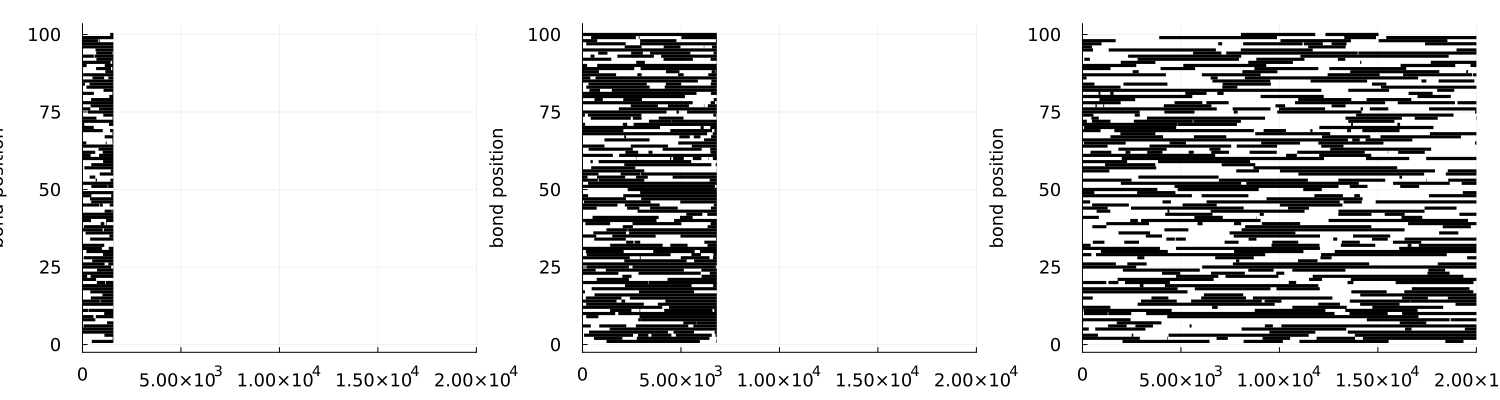

In [ ]:
function visualise_bonds(loading, n_init)
    n = 100 # Number of bonds
    l = 1.0 # Distance between bonds (unitless)
    duration = 20000
    dt = 1.0

    tension_bond, n_timesteps = loading_stochastic_model(loading, n, duration, dt)

    # setup cluster
    model = SlipBondModel((k_on_0=k_on_0,), (k_off_0=k_off_0, f_1e=f_1e))
    x = Cluster(n, l, model, :force_global)
    x = initialise_bonds_state(x, n_init)
    
    # Run the Montecarlo simulation until it breaks or it reaches the maximum number of iterations
    state, force_break, time_break, step, p = runcluster_plot(x, tension_bond, duration/n_timesteps, max_steps = n_timesteps, verbose=true)
    xlims!(p, 0, time_break)
    plot!(p, xlabel="time (s)", label="bond position", ylabel="bond position", title="", color="black", size=(550, 500), linewidth=3, xlims=(0, 20000),
          legend=:bottomright, tickfontsize=12, legendfontsize=12, guidefontsize=12, margin=4Plots.mm)
    # Output the results
    println("Force at break: ", force_break)
    println("Time at break: ", time_break)
    return p
end

# Run the simulation for the first tension value
loading = square_cycle_uneven_new(gamma_high, gamma_low, 1900, 2000)
p1 = visualise_bonds(loading, n_init)

# Run the simulation for the first tension value
loading = square_cycle_uneven_new(gamma_high, gamma_low, 1000, 1000)
p2 = visualise_bonds(loading, n_init)

# Run the simulation for the first tension value
loading = square_cycle_uneven_new(gamma_high, gamma_low, 100, 1900)
p3 = visualise_bonds(loading, n_init)

plot(p1, p2, p3, layout=(1, 3), size=(1500,400))

### d-f

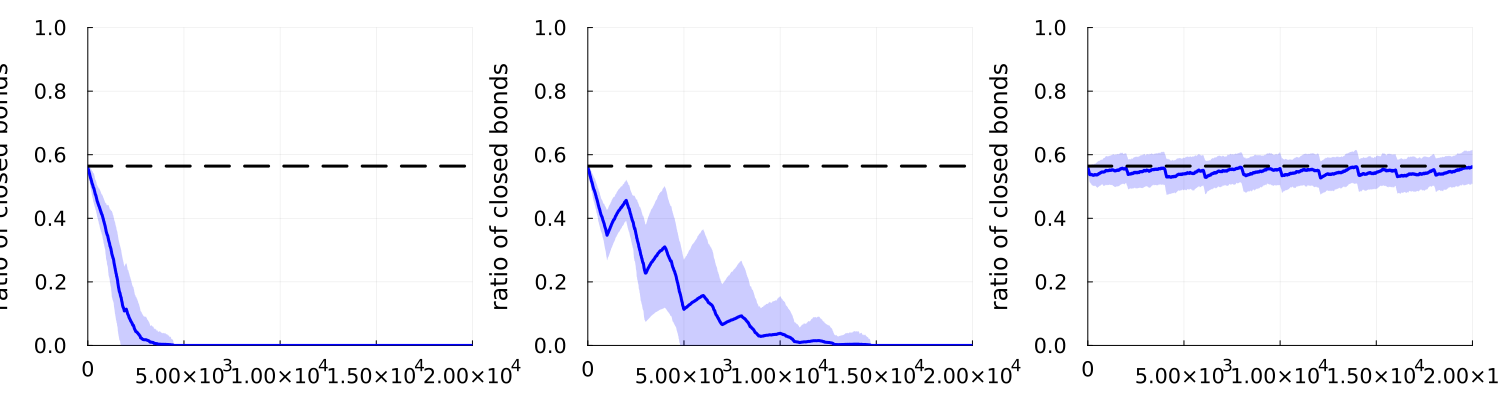

In [66]:
function run_stochastic_sim(loading, n_init, n, num_sim, gamma_low)
    duration = 20000
    dt = 1.0
    l = 1
    tension_bond, n_timesteps = loading_stochastic_model(loading, n, duration, dt)
    model = SlipBondModel((k_on_0=k_on_0,), (k_off_0=k_off_0, f_1e=f_1e)) 

    bond_memories = zeros(num_sim, n_timesteps+1)
    @threads for sim in 1:num_sim 
        x = Cluster(n, l, model, :force_global)
        x = initialise_bonds_state(x, n_init)
        _, _, _, _, bond_memories[sim,:] = runcluster_with_bond_history(x, tension_bond, dt, max_steps = n_timesteps, verbose=false, return_bond_history=true)
    end

    bond_memories[bond_memories .!= bond_memories] .= 0
    bond_memories_mean = mean(bond_memories./n, dims=1)[1,:]
    bond_memories_std = std(bond_memories./n, dims=1)[1,:]

    # Plot solution
    time = LinRange(0, duration, n_timesteps+1)
    p = plot(time, bond_memories_mean,  ribbon = bond_memories_std, fillalpha = 0.2, xlabel="time(s)", label="", ylabel="ratio of closed bonds", title="", color="blue", xlims=(0,20000),size=(550, 500),linewidth=3, legend=:topright, guidefontsize=16, tickfontsize=14, legendfontsize=14, margin=5Plots.mm)
    p = hline!(p, [n_stable], label="", linestyle=:dash, linewidth=3, color="black")
    p = hline!(p, [n_unstable], label="", linestyle=:dash, linewidth=3, color="red")
    # p = yticks!(p, 0:0.2:1)
    p = xlims!(p, 0, 20000)
    p = ylims!(p, 0, 1)
    return p
end

n = 100
num_sim = 100

# Adjust (t_h, t_l) to test three different regimes: (1900,100), (1000,1000), (100,1900)
loading = square_cycle_uneven_new(gamma_high, gamma_low, 1900, 100)
p1 = run_stochastic_sim(loading, n_init, n, num_sim, gamma_low)

loading = square_cycle_uneven_new(gamma_high, gamma_low, 1000, 1000)
p2 = run_stochastic_sim(loading, n_init, n, num_sim, gamma_low)

loading = square_cycle_uneven_new(gamma_high, gamma_low, 100, 1900)
p3 = run_stochastic_sim(loading, n_init, n, num_sim, gamma_low)

plot(p1, p2, p3, layout=(1, 3), size=(1500,400))

### g-i

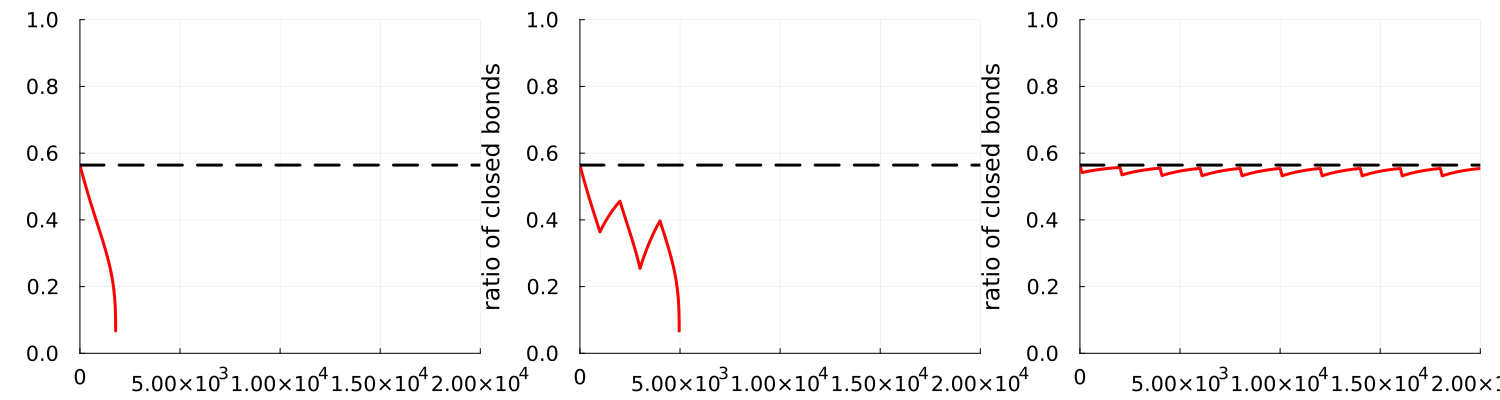

In [5]:
loading = square_cycle_uneven_new(gamma_high, gamma_low, 1900, 100)
sol = @suppress solve_dn_dt(n_stable, k_on_0, k_off_0, f_1e, loading, duration)
fracture = find_fracture(sol)
p1 = plot(sol.t[sol.t.<=fracture][2:20:end], sol.n_ratio[sol.t.<=fracture][2:20:end],  xlabel="time (s)", label="", ylabel="ratio of closed bonds", title="", color="red", size=(550, 500),linewidth=3, legend=:topright, guidefontsize=16, tickfontsize=14, legendfontsize=14, margin=3Plots.mm)
p1 = hline!(p1, [n_stable], label="", linestyle=:dash, linewidth=3, color="black")
p1 = hline!(p1, [n_unstable], label="", linestyle=:dash, linewidth=3, color="red")
p1 = ylims!(p1, 0.0, 1.0)
p1 = xlims!(p1, 0, 20000)


loading = square_cycle_uneven_new(gamma_high, gamma_low, 1000, 1000)
sol = @suppress solve_dn_dt(n_stable, k_on_0, k_off_0, f_1e, loading, duration)
fracture = find_fracture(sol)
p2 = plot(sol.t[sol.t.<=fracture][2:20:end], sol.n_ratio[sol.t.<=fracture][2:20:end],  xlabel="time (s)", label="", ylabel="ratio of closed bonds", title="", color="red", size=(550, 500),linewidth=3, legend=:topright, guidefontsize=16, tickfontsize=14, legendfontsize=14, margin=3Plots.mm)
p2 = hline!(p2, [n_stable], label="", linestyle=:dash, linewidth=3, color="black")
p2 = hline!(p2, [n_unstable], label="", linestyle=:dash, linewidth=3, color="red")
p2 = ylims!(p2, 0.0, 1.0)
p2 = xlims!(p2, 0, 20000)

loading = square_cycle_uneven_new(gamma_high, gamma_low, 100, 1900)
sol = @suppress solve_dn_dt(n_stable, k_on_0, k_off_0, f_1e, loading, duration)
fracture = find_fracture(sol)
p3 = plot(sol.t[sol.t.<=fracture][2:20:end], sol.n_ratio[sol.t.<=fracture][2:20:end],  xlabel="time (s)", label="", ylabel="ratio of closed bonds", title="", color="red", size=(550, 500),linewidth=3, legend=:topright, guidefontsize=16, tickfontsize=14, legendfontsize=14, margin=3Plots.mm)
p3 = hline!(p3, [n_stable], label="", linestyle=:dash, linewidth=3, color="black")
p3 = hline!(p3, [n_unstable], label="", linestyle=:dash, linewidth=3, color="red")
p3 = ylims!(p3, 0.0, 1.0)
p3 = xlims!(p3, 0, 20000)

plot(p1, p2, p3, layout=(1, 3), size=(1500,400))